In [29]:
import seaborn as sns
import json
from matplotlib import pyplot
import numpy as np
import matplotlib.pyplot as plt

In [30]:
def extend(lst, desired_length, fill_value=None):
    return lst + [fill_value] * (desired_length - len(lst))

In [31]:
# Angle between two vectors in degrees.
def vang(a, b): 
    return np.arccos(a.dot(b)) / np.pi * 180

# Vector from two angles
def vec(x):
    return np.array([np.cos(x[0]) * np.sin(x[1]), np.sin(x[0]) * np.sin(x[1]), np.cos(x[1])])

# convert in-game angles to radian coordiantes
def gamea(a, b):
    return [b / 180 * np.pi, (90 - a) / 180 * np.pi]

# pixels distance between two vectors (a,b) and (c,d) defined by in-game angles.
def points(a, b, c, d):
    # 3/4 seems to be a change in game engine?
    return vang(vec(gamea(a, b)), vec(gamea(c, d))) / 0.022

def vector_length(x, y):
    return np.sqrt(x * x + y * y)

def diff(a, b):
#     return sum([abs(x[0] - x[1]) for x in zip(a, b)])
#     return pow(sum(d), 0.5)
    d = [pow(x[0] - x[1], 2) for x in zip(a, b)]
    return sum([max(x - 3, 0) for x in d])

def dist_score(x):
    return np.exp(-0.0004 * np.power(x, 2))

def rc_score(r1, r2):
    return 100 * np.mean([dist_score(vector_length(r1['x'][i] - r2['x'][i], r1['y'][i] - r2['y'][i])) for i in range(len(r1['x']))])

def median_delta_recoil(rc):
    mx = [0]
    my = [0]
    x = 0
    y = 0
    n = len(rc[0]['x'])
    for i in range(1, n):
        dx = []
        dy = []
        for r in rc:
            dx.append(r['x'][i] - r['x'][i-1])
            dy.append(r['y'][i] - r['y'][i-1])
        x += np.median(dx)
        y += np.median(dy)
        mx.append(np.round(x, 1))
        my.append(np.round(y, 1))
    return mx, my

def mean_recoil(rc):
    mx = [0]
    my = [0]
    x = 0
    y = 0
    n = len(rc[0]['x'])
    for i in range(1, n):
        dx = []
        dy = []
        for r in rc:
            dx.append(r['x'][i])
            dy.append(r['y'][i])
        x = np.mean(dx)
        y = np.mean(dy)
        mx.append(np.round(x, 1))
        my.append(np.round(y, 1))
    return mx, my

In [32]:
def rpm(name):
  with open('../client/specs.json') as f:
    specs = json.load(f)
  for x in specs:
    if x['name'] == name:
      return x['rpm']
  return 1

In [33]:
np.round(points(11.27, -141.19, 0.91, -142.22), 2)

np.float64(473.2)

In [34]:
def to_game_distances(r):
  [ia, ib] = r['anchor_indexes']
  xa, ya = r['x'][ia], r['y'][ia]
  xb, yb = r['x'][ib], r['y'][ib]
  dg = r['anchor_in_game_distance']
  d = vector_length(xb - xa, yb - ya)
  r['x'] = [x * dg / d for x in r['x']]
  r['y'] = [y * dg / d for y in r['y']]
  return r

def get_recoils(w):
  with open('../client/raw_recoils.json') as f:
    raw = json.load(f)
  return [to_game_distances(x) for x in raw if x['weapon'] == w]

# recoils 3
"x": [0, 5.4, -5.7, -13.9, -30.4, -31.7, -45.1, -59.8, -52.8, -37.7, -37.8, -28.9, -6.7, 2.8, 9.3, -14.6, -33.7, -55.3, -41.3, -19.0, -10.0, 9.6, 20.7, 20.1, 11.0, 1.8, 0.7],
"y": [0, -34.6, -65.6, -98.8, -132.9, -166.6, -210.0, -235.1, -271.9, -304.2, -345.8, -362.3, -357.7, -367.9, -380.6, -396.3, -396.3, -406.8, -421.0, -420.2, -426.2, -420.2, -423.3, -438.7, -452.0, -454.1, -473.6],
"time_points": [0, 64, 129, 193, 258, 322, 387, 451, 516, 580, 645, 709, 774, 838, 903, 967, 1032, 1096, 1161, 1225, 1290, 1354, 1419, 1483, 1548, 1612, 1677],
27 27 27 27


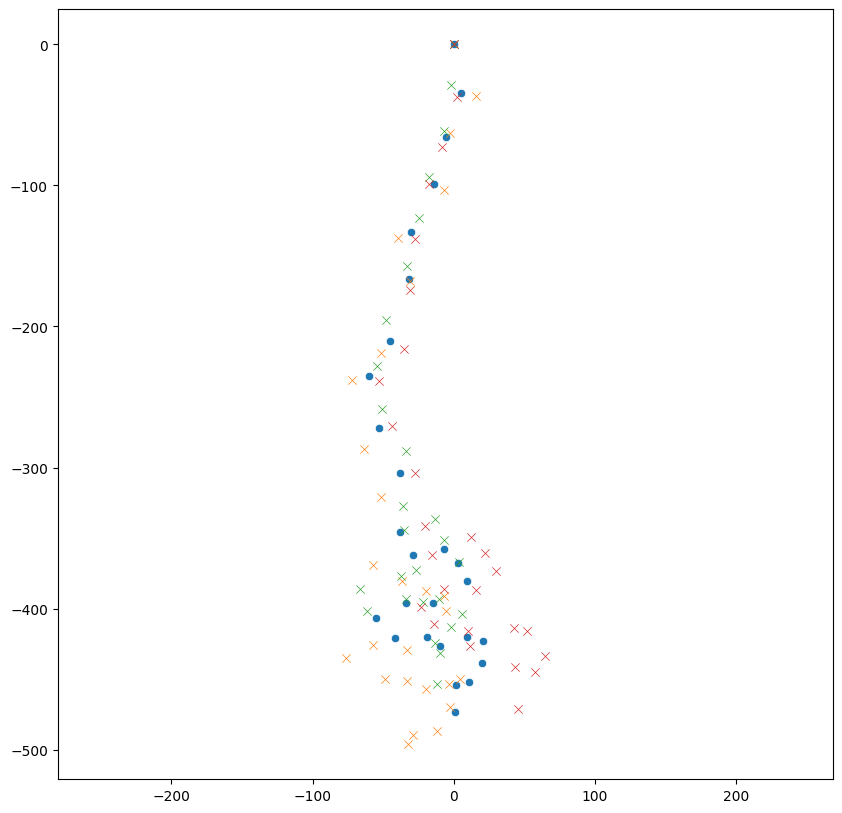

In [35]:
w = 'car'
rc = get_recoils(w)
print('# recoils', len(rc))

_, ax = plt.subplots(figsize=(10,10))
plt.axis('equal')

n = len(rc[0]['x'])
wrpm = rpm(w)

x, y = mean_recoil(rc)
sns.scatterplot(ax=ax, x=x, y=y)

for r in rc:
    sns.scatterplot(ax=ax, x=r['x'], y=r['y'], marker='x')

t = [int(i * 60.0 * 1000 / wrpm) for i in range(n)]

s = json.dumps({
    'x': x,
    'y': y,
    'time_points': t,
    })
print(s.replace('], ','],\n')[1:-1] + ',')
print(n, len(x), len(y), len(t))

In [36]:
if len(rc) > 2:
  for i in range(len(rc)):
    sub = rc[:i] + rc[i+1:]
    tx, ty = mean_recoil(sub)
    print('w/o', i, ':', np.mean([rc_score(r, {'x': tx, 'y': ty}) for r in sub]))
else:
  print('not enough patterns')
# tx, ty = mean_delta_recoil(rc)
# print('mean_delta_recoil', np.mean([rc_score(r, {'x': tx, 'y': ty}) for r in rc]))
# tx, ty = median_delta_recoil(rc)
# print('median_delta_recoil', np.mean([rc_score(r, {'x': tx, 'y': ty}) for r in rc]))
# tx, ty = mean_delta2_recoil(rc)
# print('mean_delta2_recoil', np.mean([rc_score(r, {'x': tx, 'y': ty}) for r in rc]))

w/o 0 : 87.24183409676962
w/o 1 : 80.18397840323951
w/o 2 : 83.5800077973734


In [37]:
k = len(rc) - 1
err = [0] * k
# maxerr = [0] * len(rc)
# minerr = [100000000] * len(rc)
tx, ty = mean_abs_recoil(rc)
for i in range(200):
    t = np.random.permutation(rc)
    for j in range(k):
        x, y = mean_recoil(t[:j+1])
        d = diff(x, tx) + diff(y, ty)
        err[j] += d
        # minerr[j] = min(minerr[j], d)
        # maxerr[j] = max(maxerr[j], d)

bd = 0
bi = 0
for i, r in enumerate(rc):
    print(i, r['comment'], rc_score(r, {'x': tx, 'y': ty}))
    d = diff(r['x'][:n], tx) + diff(r['y'][:n], ty)
    if d > bd:
        bd = d
        bi = i
print('bad', bi, rc[bi]['comment'])
plt.yscale('log')
plt.ylim(1, None)
sns.lineplot(x=range(k), y=err)
d = err[-2] / err[0]
d, d < 0.01, [rc_score(r, {'x': tx, 'y': ty}) for r in rc], 'err', err

NameError: name 'mean_abs_recoil' is not defined